# Spam Mail Prediction

## Problem Statement

#### Email has become one of the most widely used communication methods, but the increasing volume of spam emails creates security risks, wastes users' time, and reduces productivity. Manually identifying spam emails is inefficient and error prone. Therefore, the goal of this project is to develop a machine learning model that can automatically classify incoming emails as Spam or Ham (Not Spam) based on their textual content, improving email filtering accuracy and reducing unwanted messages.

## 1.Import necessary Libraries 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

import pickle

In [2]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install lightgbm




[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install catboost


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2.Import Dataset

In [5]:
mail_data=pd.read_csv("mail_data.csv")
mail_data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


## 3. Data understanding

In [6]:
mail_data.shape

(5572, 2)

In [7]:
mail_data.isna().sum()

Category    0
Message     0
dtype: int64

#### In this Data set there is no null entries

In [8]:
mail_data.duplicated().sum()

np.int64(415)

In [9]:
duplicates=mail_data[mail_data.duplicated(keep=False)]
duplicates.sort_values(by="Message")

,Category,Message
2124,spam,#ERROR!
717,spam,#ERROR!
505,spam,#ERROR!
2163,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1373,ham,1) Go to write msg 2) Put on Dictionary mode 3...
...,...,...
1381,ham,i dnt wnt to tlk wid u
4004,ham,somewhere out there beneath the pale moon ligh...
1412,ham,somewhere out there beneath the pale moon ligh...
2389,ham,wiskey Brandy Rum Gin Beer Vodka Scotch Shampa...


In [10]:
mail_data.drop_duplicates(inplace=True)

In [11]:
mail_data.duplicated().sum()

np.int64(0)

In [12]:
mail_data.shape

(5157, 2)

#### After, Drop the duplicates the dataset contains 5157 observations across 2 parameters

In [13]:
mail_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5157 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5157 non-null   object
 1   Message   5157 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB


In [14]:
mail_data.value_counts()

Category  Message                                                                                                                                                                                                                                                                                                                                                                                                                                                                      
spam      we tried to contact you re your response to our offer of a new nokia fone and camcorder hit reply or call 08000930705 for delivery                                                                                                                                                                                                                                                                                                                                               1
ham       &lt;#&gt;  am I think? Should say on syll

### 3.1 Exploratory Data Analysis

#### 3.1.1 Class distribution chart

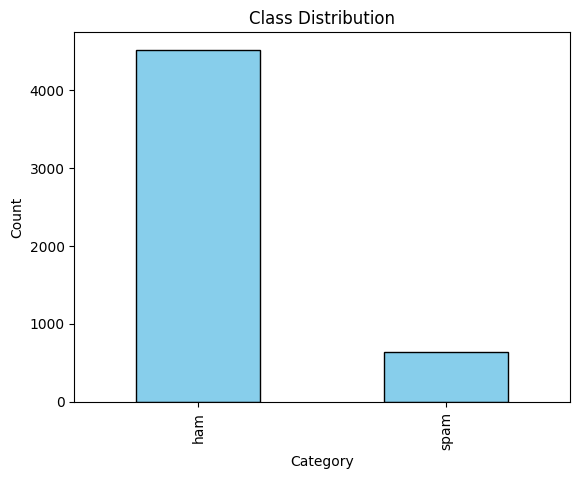

In [15]:
mail_data["Category"].value_counts().plot(kind="bar",color="skyblue",edgecolor="black")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

#### 3.1.2 Analyse the Message length

In [16]:
mail_data["Message_lenghth"]=mail_data["Message"].apply(len)

In [17]:
mail_data.head()

,Category,Message,Message_lenghth
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


##### Now,check the category wise average length 

In [18]:
mail_data.groupby(by="Category")["Message_lenghth"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_lenghth, dtype: float64

##### Here,we can understand clearly understand the spam message length was to high compared to normal message

#### Visualization

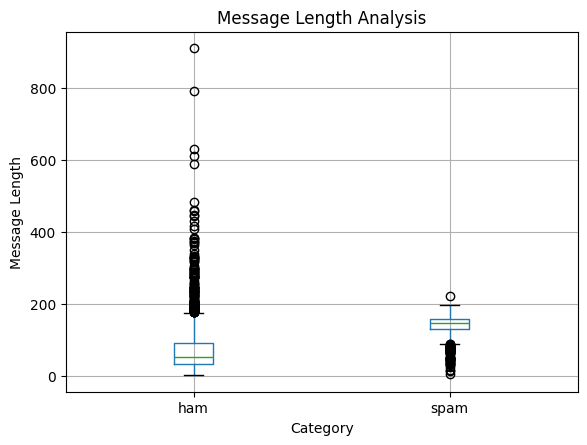

In [19]:
mail_data.boxplot(column="Message_lenghth",by="Category")
plt.ylabel("Message Length")
plt.suptitle("")
plt.title("Message Length Analysis")
plt.show()

### 4. Data Preparation

#### To Convert the Ham and Spam into 0 and 1 

In [20]:
mail_data["Category"]=mail_data["Category"].map({"ham":0,"spam":1})

In [21]:
mail_data.head()

,Category,Message,Message_lenghth
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


### Split the Input and Output for model prediction

In [22]:
X=mail_data["Message"]
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5157, dtype: object

In [23]:
Y=mail_data["Category"]
Y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: Category, Length: 5157, dtype: int64

In [24]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

### 5.TF-IDF vectorization

In [25]:
vectorizer=TfidfVectorizer()

X_train=vectorizer.fit_transform(X_train)
X_test=vectorizer.transform(X_test)

### 6.Model Building

#### 6.1 Create model

In [26]:
Model=LogisticRegression()
Model


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 6.2 Train model

In [27]:
Model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### 6.3 Model Prediction

In [28]:
Y_predict=Model.predict(X_test)

In [29]:
print(Y_predict)

[0 1 0 ... 0 0 0]


### 7 Model Evaluation

In [30]:
accuracy=accuracy_score(Y_test,Y_predict)
Confusion_matrix=confusion_matrix(Y_test, Y_predict)
Classification_report=classification_report(Y_test,Y_predict)
precision=precision_score(Y_test,Y_predict)
recall=recall_score(Y_test,Y_predict)
F1_score=f1_score(Y_test,Y_predict)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)


Accuracy: 0.9709302325581395
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.97      1.00      0.98       896
           1       0.98      0.79      0.88       136

    accuracy                           0.97      1032
   macro avg       0.98      0.90      0.93      1032
weighted avg       0.97      0.97      0.97      1032

Precision Score: 0.9818181818181818
Recall Score: 0.7941176470588235
F1 Score 0.8780487804878049


In [31]:
Confusion_matrix=confusion_matrix(Y_test, Y_predict)
print("Confusion Matrix:",confusion_matrix)

Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>


### 8.Regularization Model

#### 8.1 Decision Tree

##### Create Model

In [32]:
Decision_Tree_Model=DecisionTreeClassifier()

##### Train Model


In [33]:
Decision_Tree_Model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


##### Model Prediction

In [34]:
Y_predict_Decision=Decision_Tree_Model.predict(X_test)
Y_predict_Decision

array([0, 0, 0, ..., 0, 0, 0], shape=(1032,))

#### Model Evaluation for Decision Tree

In [35]:
accuracy=accuracy_score(Y_test,Y_predict_Decision)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_Decision)
Classification_report=classification_report(Y_test,Y_predict_Decision)
precision=precision_score(Y_test,Y_predict_Decision)
recall=recall_score(Y_test,Y_predict_Decision)
F1_score=f1_score(Y_test,Y_predict_Decision)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)


Accuracy: 0.9622093023255814
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.98      0.98       896
           1       0.86      0.85      0.86       136

    accuracy                           0.96      1032
   macro avg       0.92      0.91      0.92      1032
weighted avg       0.96      0.96      0.96      1032

Precision Score: 0.8646616541353384
Recall Score: 0.8455882352941176
F1 Score 0.8550185873605948


#### 8.2 Random Forest

##### Create Model

In [36]:
Random_Forest_Model=RandomForestClassifier()

##### Train Model

In [37]:
Random_Forest_Model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### ModelPrediction

In [38]:
Y_predict_RF=Random_Forest_Model.predict(X_test)
Y_predict_RF

array([0, 0, 0, ..., 0, 0, 0], shape=(1032,))

##### Model Evaluation

In [39]:
accuracy=accuracy_score(Y_test,Y_predict_RF)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_RF)
Classification_report=classification_report(Y_test,Y_predict_RF)
precision=precision_score(Y_test,Y_predict_RF)
recall=recall_score(Y_test,Y_predict_RF)
F1_score=f1_score(Y_test,Y_predict_RF)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9796511627906976
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       0.99      0.85      0.92       136

    accuracy                           0.98      1032
   macro avg       0.98      0.93      0.95      1032
weighted avg       0.98      0.98      0.98      1032

Precision Score: 0.9914529914529915
Recall Score: 0.8529411764705882
F1 Score 0.9169960474308301


#### 8.3 KNN 

##### Create Model

In [40]:
KNN_Model=KNeighborsClassifier(n_neighbors=5)

##### Train Model

In [41]:
KNN_Model.fit(X_train,Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


##### Model Prediction

In [42]:
Y_predict_KNN=KNN_Model.predict(X_test)
Y_predict

array([0, 1, 0, ..., 0, 0, 0], shape=(1032,))

##### Model Evaluation

In [43]:
accuracy=accuracy_score(Y_test,Y_predict_KNN)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_KNN)
Classification_report=classification_report(Y_test,Y_predict_KNN)
precision=precision_score(Y_test,Y_predict_KNN)
recall=recall_score(Y_test,Y_predict_KNN)
F1_score=f1_score(Y_test,Y_predict_KNN)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9079457364341085
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.90      1.00      0.95       896
           1       1.00      0.30      0.46       136

    accuracy                           0.91      1032
   macro avg       0.95      0.65      0.71      1032
weighted avg       0.92      0.91      0.89      1032

Precision Score: 1.0
Recall Score: 0.3014705882352941
F1 Score 0.4632768361581921


#### 8.4 Naive Bayes

##### Create Model

In [44]:
Naive_Bayes_Model=MultinomialNB()


##### Train Model

In [45]:
Naive_Bayes_Model.fit(X_train,Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


##### Model Prediction

In [46]:
Y_predict_NB=Naive_Bayes_Model.predict(X_test)
Y_predict_NB

array([0, 0, 0, ..., 0, 0, 0], shape=(1032,))

##### Model Evaluation

In [47]:
accuracy=accuracy_score(Y_test,Y_predict_NB)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_NB)
Classification_report=classification_report(Y_test,Y_predict_NB)
precision=precision_score(Y_test,Y_predict_NB)
recall=recall_score(Y_test,Y_predict_NB)
F1_score=f1_score(Y_test,Y_predict_NB)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9525193798449613
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.95      1.00      0.97       896
           1       1.00      0.64      0.78       136

    accuracy                           0.95      1032
   macro avg       0.97      0.82      0.88      1032
weighted avg       0.95      0.95      0.95      1032

Precision Score: 1.0
Recall Score: 0.6397058823529411
F1 Score 0.7802690582959642


#### 8.5 SVM

##### Create model

In [48]:
SVM_Model=SVC()

#### Train Model

In [49]:
SVM_Model.fit(X_train,Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


##### Model Prediction

In [50]:
Y_predict_SVM=SVM_Model.predict(X_test)

##### Model Evaluation

In [51]:
accuracy=accuracy_score(Y_test,Y_predict_SVM)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_SVM)
Classification_report=classification_report(Y_test,Y_predict_SVM)
precision=precision_score(Y_test,Y_predict_SVM)
recall=recall_score(Y_test,Y_predict_SVM)
F1_score=f1_score(Y_test,Y_predict_SVM)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9854651162790697
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.99      1.00      0.99       896
           1       0.98      0.90      0.94       136

    accuracy                           0.99      1032
   macro avg       0.98      0.95      0.97      1032
weighted avg       0.99      0.99      0.99      1032

Precision Score: 0.984
Recall Score: 0.9044117647058824
F1 Score 0.9425287356321839


#### 8.6 XG Boost

##### Create Model

In [52]:
XG_Model=XGBClassifier()

##### Train model

In [53]:
XG_Model.fit(X_train,Y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


##### Model Prediction

In [54]:
Y_predict_XG=XG_Model.predict(X_test)

##### Model Evaluation

In [55]:
accuracy=accuracy_score(Y_test,Y_predict_XG)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_XG)
Classification_report=classification_report(Y_test,Y_predict_XG)
precision=precision_score(Y_test,Y_predict_XG)
recall=recall_score(Y_test,Y_predict_XG)
F1_score=f1_score(Y_test,Y_predict_XG)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9699612403100775
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.99      0.98       896
           1       0.92      0.85      0.88       136

    accuracy                           0.97      1032
   macro avg       0.95      0.92      0.93      1032
weighted avg       0.97      0.97      0.97      1032

Precision Score: 0.92
Recall Score: 0.8455882352941176
F1 Score 0.8812260536398467


#### 8.7 LGBM

##### Create Model

In [56]:
LGBM_Model=LGBMClassifier()

##### Train Model

In [57]:
LGBM_Model.fit(X_train,Y_train)

[LightGBM] [Info] Number of positive: 505, number of negative: 3620
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011985 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12376
[LightGBM] [Info] Number of data points in the train set: 4125, number of used features: 442
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122424 -> initscore=-1.969671
[LightGBM] [Info] Start training from score -1.969671


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


##### Model prediction

In [58]:
Y_predict_LGBM=LGBM_Model.predict(X_test)


##### Model Evaluation

In [59]:
accuracy=accuracy_score(Y_test,Y_predict_LGBM)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_LGBM)
Classification_report=classification_report(Y_test,Y_predict_LGBM)
precision=precision_score(Y_test,Y_predict_LGBM)
recall=recall_score(Y_test,Y_predict_LGBM)
F1_score=f1_score(Y_test,Y_predict_LGBM)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9796511627906976
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       0.97      0.88      0.92       136

    accuracy                           0.98      1032
   macro avg       0.97      0.94      0.95      1032
weighted avg       0.98      0.98      0.98      1032

Precision Score: 0.967479674796748
Recall Score: 0.875
F1 Score 0.918918918918919


#### 8.8 CatBoost

##### Create Model

In [60]:
CatBoost_Model=CatBoostClassifier(iterations=200,learning_rate=0.1,depth=6,random_state=42,verbose=0)


##### Train Model

In [61]:
CatBoost_Model.fit(X_train,Y_train)

CatBoostClassifier(depth=6, iterations=200, learning_rate=0.1, random_state=42, verbose=0)

##### Model Prediction

In [62]:
Y_predict_CatBoost=CatBoost_Model.predict(X_test)

##### Model Evaluation

In [63]:
accuracy=accuracy_score(Y_test,Y_predict_CatBoost)
Confusion_matrix=confusion_matrix(Y_test, Y_predict_CatBoost)
Classification_report=classification_report(Y_test,Y_predict_CatBoost)
precision=precision_score(Y_test,Y_predict_CatBoost)
recall=recall_score(Y_test,Y_predict_CatBoost)
F1_score=f1_score(Y_test,Y_predict_CatBoost)

print("Accuracy:",accuracy)
print("Confusion Matrix:",confusion_matrix)
print("Classification Report:",Classification_report)
print("Precision Score:",precision)
print("Recall Score:",recall)
print("F1 Score",F1_score)

Accuracy: 0.9777131782945736
Confusion Matrix: <function confusion_matrix at 0x00000231E48BA710>
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.99      0.99       896
           1       0.96      0.87      0.91       136

    accuracy                           0.98      1032
   macro avg       0.97      0.93      0.95      1032
weighted avg       0.98      0.98      0.98      1032

Precision Score: 0.959349593495935
Recall Score: 0.8676470588235294
F1 Score 0.9111969111969112


### 8.Model Saving

In [64]:
Save_pkl=pickle.dump(Model,open("Spam_main_prediction.pkl","wb"))
print("Model is Successfully Saved as Pkl file!!")

Model is Successfully Saved as Pkl file!!
